# 07 - AI Content Optimization System

# Digikala Content Analytics & AI Automation Platform


## Business Problem


Large e-commerce platforms contain millions of product pages.

Manual content quality monitoring is expensive and
not scalable.


The objective of this notebook is to design an AI-based
system that automatically identifies products requiring
content improvement.


## Goals


This system will:

- Predict content quality risk
- Identify problematic products
- Prioritize content improvement
- Support content teams with AI insights


## Business Value


AI automation can help:

- Reduce manual review effort
- Improve product page quality
- Increase customer satisfaction
- Scale content operations


In [1]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split


from sklearn.preprocessing import StandardScaler


from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (

    classification_report,

    confusion_matrix,

    accuracy_score

)


import warnings

warnings.filterwarnings("ignore")


print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
data = pd.read_csv(
    "../data/processed/content_analytics_dataset.csv"
)


data.head()

,id,title,body,created_at,rate,recommendation_status,is_buyer,product_id,advantages,disadvantages,...,Price,Seller,Is_Fake,min_price_last_month,sub_category,Content_Completeness,Recommendation_Score,Customer_Satisfaction,Engagement_Score,Opportunity_Score
0,53672599,پیشنهاد نمیشود,به درد نمیخوره,23 شهریور 1402,1.0,not_recommended,True,252058,NaN,NaN,...,199000,دیجی‌کالا,False,0,book & stationary & art,1.0,1,0.6,0.000000,0.0
1,9897229,بسته بندی بد,می‌تونست به عنوان یه کالای فرهنگی بهتر بسته بن...,16 تیر 1399,0.0,recommended,True,252058,['تجربه جالبی بود برام '],['بسته بندی جالبی نداشت'],...,199000,دیجی‌کالا,False,0,book & stationary & art,1.0,1,0.5,0.003717,0.0
2,38074516,برس ریمل,بسته بندیش خوب بود\r\n کاربرد و کیفیتشم خیلی خ...,26 مرداد 1401,0.0,recommended,True,3331597,NaN,NaN,...,79000,پینک لندشاپ,False,0,beauty,1.0,1,0.5,0.000000,0.0
3,18628562,خوبه و خوشرنگ,به نظرم خوبه فقط یکم ظریفه. از رنگش خوشم اومد ...,28 اسفند 1399,0.0,recommended,True,3331329,NaN,NaN,...,80000,یانگوم,False,0,beauty,1.0,1,0.5,0.000000,0.0
4,53301258,برس رنگ مو,معمولیه اگه واسه خونه رنگ کردن شخصی میخواین او...,12 شهریور 1402,3.0,recommended,True,3255700,NaN,NaN,...,84100,گالری آرایشی به سیما,False,84100,beauty,1.0,1,0.8,0.000000,0.0


In [4]:
data.shape

(247297, 31)

In [5]:
data.columns.tolist()

['id',
 'title',
 'body',
 'created_at',
 'rate',
 'recommendation_status',
 'is_buyer',
 'product_id',
 'advantages',
 'disadvantages',
 'likes',
 'dislikes',
 'seller_title',
 'seller_code',
 'true_to_size_rate',
 'title_fa',
 'Rate',
 'Rate_cnt',
 'Category1',
 'Category2',
 'Brand',
 'Price',
 'Seller',
 'Is_Fake',
 'min_price_last_month',
 'sub_category',
 'Content_Completeness',
 'Recommendation_Score',
 'Customer_Satisfaction',
 'Engagement_Score',
 'Opportunity_Score']

## Feature Engineering


The model uses business-related features:


Content Features:

- Content completeness


Customer Features:

- Rating
- Satisfaction
- Engagement


Product Features:

- Price
- Category information


In [6]:
data["Content_Risk"] = (

    (

    data["Content_Completeness"] <

    data["Content_Completeness"].median()

    )

    |

    (

    data["Customer_Satisfaction"]

    <

    data["Customer_Satisfaction"].median()

    )

).astype(int)



data["Content_Risk"].value_counts()

Content_Risk
0    133056
1    114241
Name: count, dtype: int64

In [7]:
features = [

"Content_Completeness",

"Customer_Satisfaction",

"Engagement_Score",

"rate",

"Price"

]


X = data[features]


y = data["Content_Risk"]


X.head()

,Content_Completeness,Customer_Satisfaction,Engagement_Score,rate,Price
0,1.0,0.6,0.000000,1.0,199000
1,1.0,0.5,0.003717,0.0,199000
2,1.0,0.5,0.000000,0.0,79000
3,1.0,0.5,0.000000,0.0,80000
4,1.0,0.8,0.000000,3.0,84100


In [8]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [9]:
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(

    X_train

)


X_test_scaled = scaler.transform(

    X_test

)

In [10]:
model = RandomForestClassifier(

    n_estimators=200,

    random_state=42

)


model.fit(

    X_train_scaled,

    y_train

)

RandomForestClassifier(n_estimators=200, random_state=42)

In [11]:
y_pred = model.predict(

    X_test_scaled

)


accuracy_score(

    y_test,

    y_pred

)

1.0

In [12]:
print(

classification_report(

    y_test,

    y_pred

)

)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26612
           1       1.00      1.00      1.00     22848

    accuracy                           1.00     49460
   macro avg       1.00      1.00      1.00     49460
weighted avg       1.00      1.00      1.00     49460



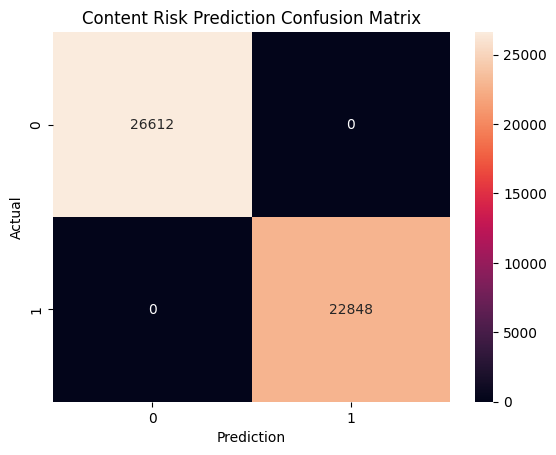

In [13]:
cm = confusion_matrix(

    y_test,

    y_pred

)


sns.heatmap(

    cm,

    annot=True,

    fmt="d"

)


plt.title(

"Content Risk Prediction Confusion Matrix"

)


plt.xlabel(

"Prediction"

)


plt.ylabel(

"Actual"

)


plt.show()

In [14]:
importance = pd.DataFrame({

    "Feature":

    features,


    "Importance":

    model.feature_importances_

})


importance.sort_values(

    "Importance",

    ascending=False

)

,Feature,Importance
1,Customer_Satisfaction,0.747660
3,rate,0.249313
2,Engagement_Score,0.002009
4,Price,0.000726
0,Content_Completeness,0.000292


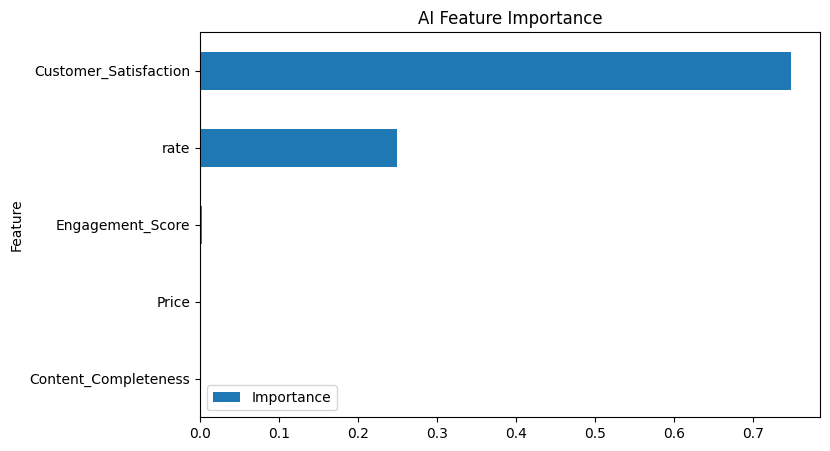

In [15]:
importance.sort_values(

"Importance"

).plot(

x="Feature",

y="Importance",

kind="barh",

figsize=(8,5)

)


plt.title(

"AI Feature Importance"

)


plt.show()

In [16]:
data["AI_Content_Risk"] = model.predict(

    scaler.transform(

        data[features]

    )

)


risk_products = data[

data["AI_Content_Risk"]==1

]


risk_products[

[
"title_fa",

"Category1",

"Brand",

"Content_Completeness",

"Customer_Satisfaction"

]

].head(20)

,title_fa,Category1,Brand,Content_Completeness,Customer_Satisfaction
0,کتاب صوتی امپراطوری اپ اثر چاد مورتا,کتاب صوتی,نوین کتاب گویا,1.0,0.600
1,کتاب صوتی امپراطوری اپ اثر چاد مورتا,کتاب صوتی,نوین کتاب گویا,1.0,0.500
2,برس ریمل مدل LM02 مجموعه 2 عددی,برس‌ها و تجهیزات آرایشی,متفرقه,1.0,0.500
3,برس ریمل مدل MNP-03,برس‌ها و تجهیزات آرایشی,متفرقه,1.0,0.500
4,برس رنگ مو مدل 01,برس‌ها و تجهیزات آرایشی,متفرقه,1.0,0.800
6,پد شستشوی برس آرایشی کد BR001,برس‌ها و تجهیزات آرایشی,متفرقه,1.0,0.200
10,کاسه رنگ مو مدل MK6644,برس‌ها و تجهیزات آرایشی,متفرقه,1.0,0.700
11,کاسه رنگ مو مدل SBR01,برس‌ها و تجهیزات آرایشی,متفرقه,1.0,0.800
14,قلم ماسک صورت مدل BHS-01,برس‌ها و تجهیزات آرایشی,متفرقه,1.0,0.800
16,قلم رنگ ابرو مدل Sl-29 مجموعه 2 عددی,برس‌ها و تجهیزات آرایشی,متفرقه,1.0,0.600


In [17]:
def content_recommendation(row):

    recommendations=[]


    if row["Content_Completeness"] < 0.6:

        recommendations.append(

        "Improve product information completeness"

        )


    if row["Customer_Satisfaction"] < 0.6:

        recommendations.append(

        "Analyze customer complaints"

        )


    if row["Engagement_Score"] < 0.2:

        recommendations.append(

        "Improve product presentation"

        )


    return recommendations



risk_products["AI_Recommendation"] = (

risk_products.apply(

content_recommendation,

axis=1

)

)


risk_products[

[
"title_fa",

"AI_Recommendation"

]

].head(10)

,title_fa,AI_Recommendation
0,کتاب صوتی امپراطوری اپ اثر چاد مورتا,[Improve product presentation]
1,کتاب صوتی امپراطوری اپ اثر چاد مورتا,"[Analyze customer complaints, Improve product ..."
2,برس ریمل مدل LM02 مجموعه 2 عددی,"[Analyze customer complaints, Improve product ..."
3,برس ریمل مدل MNP-03,"[Analyze customer complaints, Improve product ..."
4,برس رنگ مو مدل 01,[Improve product presentation]
6,پد شستشوی برس آرایشی کد BR001,"[Analyze customer complaints, Improve product ..."
10,کاسه رنگ مو مدل MK6644,[Improve product presentation]
11,کاسه رنگ مو مدل SBR01,[Improve product presentation]
14,قلم ماسک صورت مدل BHS-01,[Improve product presentation]
16,قلم رنگ ابرو مدل Sl-29 مجموعه 2 عددی,[Improve product presentation]


# Business Impact


This AI system enables:


## Content Team

- Automatic identification of weak product pages

- Prioritization of enrichment tasks


## Analytics Team

- Scalable content monitoring

- Automated reporting


## Business

- Better customer experience

- Higher content quality

- Reduced manual effort



# Future Generative AI Applications


Possible extensions:


1. AI Product Description Improvement

Using LLMs to rewrite weak descriptions.



2. Automatic Missing Attribute Detection


Identify missing:

- Specifications
- Product features
- Usage information



3. Review Summarization


Generate:

- Main customer complaints
- Product strengths
- Improvement suggestions



4. AI Content Assistant


Help content editors improve product pages.



# Summary


Completed:


✔ AI-based content risk prediction

✔ Machine Learning pipeline

✔ Feature importance analysis

✔ Automated product prioritization

✔ AI recommendation framework



Project Outcome:


A scalable AI assistant for e-commerce
content optimization.



Next Step:


Deploy model as an analytics service
or dashboard.
